# Prétraitement et Nettoyage des données 
> Réf. rapport, pp. 8-22

In [1]:
import pandas as pd
import os


### Visiualiser la data du fichier globale

In [2]:
df_all = pd.read_csv("car_data.csv")
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23068 entries, 0 to 23067
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Importé neuf                    2165 non-null   object 
 1   Nombre de portes                19835 non-null  float64
 2   Véhicule dédouané               5981 non-null   float64
 3   Carburant                       23039 non-null  object 
 4   Carrosserie                     17298 non-null  object 
 5   Voiture personnalisée (tuning)  4813 non-null   object 
 6   Boite de vitesses               23038 non-null  object 
 7   Année                           23039 non-null  float64
 8   Puissance fiscale               21649 non-null  float64
 9   Véhicule en garantie            2776 non-null   object 
 10  Nom du véhicule                 23039 non-null  object 
 11  Kilométrage                     21692 non-null  object 
 12  Prix                            

## Identifier et Sélectionner les colonnes pertinentes 

In [3]:
df_all.columns

Index(['Importé neuf', 'Nombre de portes', 'Véhicule dédouané', 'Carburant',
       'Carrosserie', 'Voiture personnalisée (tuning)', 'Boite de vitesses',
       'Année', 'Puissance fiscale', 'Véhicule en garantie', 'Nom du véhicule',
       'Kilométrage', 'Prix', 'Première main', 'Couleur', 'Date'],
      dtype='object')

In [4]:
df = df_all[["Nom du véhicule", "Année", "Kilométrage", "Carburant", "Puissance fiscale", "Boite de vitesses", "Prix"]]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23068 entries, 0 to 23067
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Nom du véhicule    23039 non-null  object 
 1   Année              23039 non-null  float64
 2   Kilométrage        21692 non-null  object 
 3   Carburant          23039 non-null  object 
 4   Puissance fiscale  21649 non-null  float64
 5   Boite de vitesses  23038 non-null  object 
 6   Prix               20700 non-null  object 
dtypes: float64(2), object(5)
memory usage: 1.2+ MB


### Afficher les 1er lignes de dataset

In [5]:
df.head()

,Nom du véhicule,Année,Kilométrage,Carburant,Puissance fiscale,Boite de vitesses,Prix
0,Volkswagen Touran 2016,2016.0,147 000,Diesel,6.0,Manuelle,225 000 Dhs
1,Peugeot 308 2017,2017.0,150 000,Diesel,6.0,Manuelle,130 000 Dhs
2,Toyota Corolla 2006,2006.0,500 000,Diesel,8.0,Manuelle,52 000 Dhs
3,Renault Clio 2020,2020.0,110 000,Diesel,7.0,Manuelle,121 000 Dhs
4,Renault Express 2022,2022.0,58 000,Diesel,6.0,Manuelle,165 000 Dhs


## Fixer les types des colonnes

In [6]:
df = df.copy()

# Convertir 'Année' en entier en gérant NaN et les valeurs invalides
df['Année'] = pd.to_numeric(df['Année'], errors='coerce').astype('Int64') 

# Convertir 'Kilométrage' en entier après suppression des espaces et gestion des NaN
df['Kilométrage'] = (
    df['Kilométrage']
    .astype(str)
    .str.replace(r'\s+', '', regex=True)
    .replace({'nan': pd.NA, '<NA>': pd.NA, '': pd.NA})
    .apply(pd.to_numeric, errors='coerce')
    .astype('Int64')
)


# Convertir 'Puissance fiscale' en entier
df['Puissance fiscale'] = pd.to_numeric(df['Puissance fiscale'], errors='coerce').astype('Int64')

# Convertir 'Prix' en entier après suppression de 'Dhs' et gestion des NaN
df['Prix'] = (
    df['Prix']
    .astype(str)
    .str.replace(' Dhs', '', regex=True)
    .str.replace(' ', '', regex=True)
    .replace({'nan': pd.NA, '<NA>': pd.NA, '': pd.NA})  
    .apply(pd.to_numeric, errors='coerce')
    .astype('Int64')
)

# Vérifier les types après conversion
print(df.dtypes)

Nom du véhicule      object
Année                 Int64
Kilométrage           Int64
Carburant            object
Puissance fiscale     Int64
Boite de vitesses    object
Prix                  Int64
dtype: object


### Vérifier les valeurs nulles des colonnes

In [7]:
df.isnull().sum()

Nom du véhicule        29
Année                  29
Kilométrage          1376
Carburant              29
Puissance fiscale    1419
Boite de vitesses      30
Prix                 2368
dtype: int64

### Supprimer les valeurs nulles

In [8]:
df = df.dropna()

### Vérifier les infos de la dataset

### Supprimer les doublons

In [9]:
df.drop_duplicates()

,Nom du véhicule,Année,Kilométrage,Carburant,Puissance fiscale,Boite de vitesses,Prix
0,Volkswagen Touran 2016,2016,147000,Diesel,6,Manuelle,225000
1,Peugeot 308 2017,2017,150000,Diesel,6,Manuelle,130000
2,Toyota Corolla 2006,2006,500000,Diesel,8,Manuelle,52000
3,Renault Clio 2020,2020,110000,Diesel,7,Manuelle,121000
4,Renault Express 2022,2022,58000,Diesel,6,Manuelle,165000
...,...,...,...,...,...,...,...
23059,Bmw Serie 5 2012,2012,190000,Diesel,8,Automatique,178000
23061,Peugeot 508 2016,2016,170000,Diesel,6,Manuelle,132000
23062,Dacia Sandero 2019,2019,35000,Diesel,6,Manuelle,125000
23064,Land-rover Range rover evoque 2018,2018,130000,Diesel,9,Automatique,300000


### Suppression de l'année dans la colonne 'Nom du véhicule'

In [10]:
df['Nom du véhicule'] = df['Nom du véhicule'].str.replace(r'\s\d{4}$', '', regex=True)

## Séparation de la colonne Nom du véhicule en Marque et Modèle

In [11]:
df[['Marque', 'Modèle']] = df['Nom du véhicule'].str.split(' ', n=1, expand=True)

## Supprimer les valeurs abberantes et incohérentes

In [12]:
def remove_outliers(df):
    # Filtrage multidimensionnel
    numeric_cols = ['Kilométrage', 'Puissance fiscale', 'Prix']
    
    # Calcul simultané pour toutes les colonnes
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    
    # Masque global
    mask = ~(
        (df[numeric_cols] < (Q1 - 1.5 * IQR)) | 
        (df[numeric_cols] > (Q3 + 1.5 * IQR))
    ).any(axis=1)
    
    # Filtrage en une seule opération
    return df[mask]

# Application avec conservation des données
df_clean = remove_outliers(df)

# Filtrage complémentaire métier
df_clean = df_clean[
    (df_clean['Année'] >= 1990) & 
    (df_clean['Kilométrage'] <= 500_000) &
    (df_clean['Puissance fiscale'].between(3, 40))
]

### Réorganiser les colonnes pertinentes

In [13]:
df_clean = df_clean[['Marque','Modèle','Année', 'Kilométrage','Carburant',
                     'Puissance fiscale', 'Boite de vitesses', 'Prix']]
df_clean.head()

,Marque,Modèle,Année,Kilométrage,Carburant,Puissance fiscale,Boite de vitesses,Prix
0,Volkswagen,Touran,2016,147000,Diesel,6,Manuelle,225000
1,Peugeot,308,2017,150000,Diesel,6,Manuelle,130000
3,Renault,Clio,2020,110000,Diesel,7,Manuelle,121000
4,Renault,Express,2022,58000,Diesel,6,Manuelle,165000
6,Volkswagen,Caddy,2021,90000,Diesel,8,Manuelle,230000


## Affichage des boxplot des variables continues

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

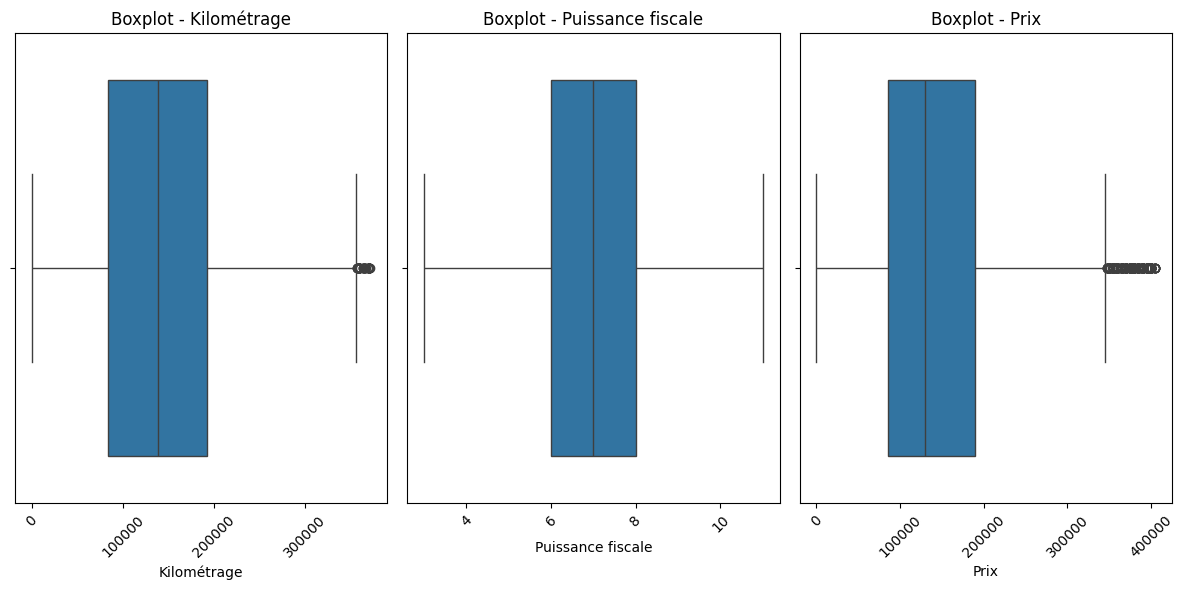

In [15]:
# Créer un boxplot pour chaque variable continue
plt.figure(figsize=(12, 6))

# Boxplot pour Kilométrage
plt.subplot(1, 3, 1)
sns.boxplot(x=df_clean['Kilométrage'])
plt.title('Boxplot - Kilométrage')
plt.xticks(rotation=45)  # Rotation des étiquettes

# Boxplot pour Puissance fiscale
plt.subplot(1, 3, 2)
sns.boxplot(x=df_clean['Puissance fiscale'])
plt.title('Boxplot - Puissance fiscale')
plt.xticks(rotation=45)  # Rotation des étiquettes

# Boxplot pour Prix
plt.subplot(1, 3, 3)
sns.boxplot(x=df_clean['Prix'])
plt.title('Boxplot - Prix')
plt.xticks(rotation=45)  # Rotation des étiquettes

# Ajustement de l'affichage
plt.tight_layout()
plt.show()

### Affichage de boxplot de Prix après suppression des outliers

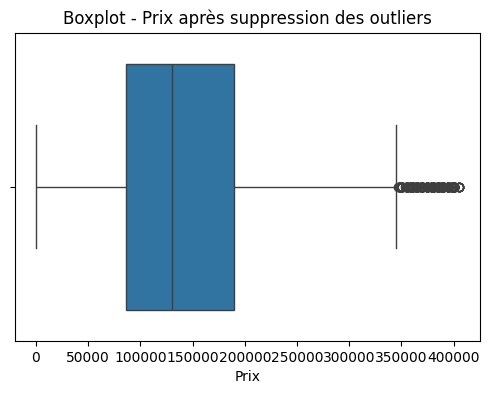

In [16]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df_clean['Prix'])
plt.title("Boxplot - Prix après suppression des outliers")
plt.show()

## Sauvegarde du fichier de la dataset clean

In [17]:
df_clean.to_csv('car_data_clean.csv', index=False)

## Encodage & Normalisation

###  Les statistiques des données brutes avant encodage et normalisation

In [18]:
df_clean.describe()

,Année,Kilométrage,Puissance fiscale,Prix
count,16030.0,16030.0,16030.0,16030.0
mean,2014.121397,142138.149033,7.179913,148874.522271
std,5.806064,78973.888517,1.373963,81348.820937
min,1990.0,1.0,3.0,1.0
25%,2011.0,84000.0,6.0,86000.0
50%,2015.0,139000.0,7.0,130000.0
75%,2018.0,193000.0,8.0,190000.0
max,2025.0,372000.0,11.0,405000.0


### Séparation de X(features) et y(target)

In [19]:
X = df_clean.drop('Prix', axis=1)
y = df_clean['Prix']

### Répartition des colonnes selon type

In [20]:
categorical_cols = ['Marque', 'Modèle', 'Carburant', 'Boite de vitesses']
numerical_cols = ['Kilométrage', 'Puissance fiscale']

### Encodage des colonnes Marque et Modèle

In [21]:
from sklearn.preprocessing import LabelEncoder

marque_encoder = LabelEncoder()
modele_encoder = LabelEncoder()

X['Marque'] = marque_encoder.fit_transform(X['Marque'].str.lower().str.strip())
X['Modèle'] = modele_encoder.fit_transform(X['Modèle'].str.lower().str.strip())

### Encodage des colonnes Carburant et Boite de vitesses

In [22]:
carburant_dummies = pd.get_dummies(X['Carburant'].str.lower(), prefix='', prefix_sep='')
for fuel in ['diesel', 'electrique', 'essence', 'hybride']:
    if fuel not in carburant_dummies.columns:
        carburant_dummies[fuel] = 0

In [23]:
X['Boite_manuelle'] = (X['Boite de vitesses'].str.lower() == 'manuelle').astype(int)

### Standardisation des cols. numériques

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled_numerical = scaler.fit_transform(X[numerical_cols])
X_numerical_df = pd.DataFrame(X_scaled_numerical, columns=numerical_cols, index=X.index)

### Création de dataset après encodage

In [25]:
X = pd.concat([
    X[['Marque', 'Modèle', 'Année']],
    X_numerical_df,
    carburant_dummies[['diesel', 'electrique', 'essence', 'hybride']],
    X[['Boite_manuelle']]
], axis=1)

###  Les statistiques des données brutes après encodage et normalisation

In [26]:
X.describe()

,Marque,Modèle,Année,Kilométrage,Puissance fiscale,Boite_manuelle
count,16030.000000,16030.000000,16030.0,1.603000e+04,1.603000e+04,16030.000000
mean,35.018403,231.997505,2014.121397,3.546065e-17,3.457413e-17,0.652277
std,18.342020,130.497298,5.806064,1.000031e+00,1.000031e+00,0.476262
min,0.000000,0.000000,1990.0,-1.799855e+00,-3.042326e+00,0.000000
25%,19.000000,130.000000,2011.0,-7.361922e-01,-8.587928e-01,0.000000
50%,41.000000,230.000000,2015.0,-3.973778e-02,-1.309484e-01,1.000000
75%,49.000000,343.000000,2018.0,6.440539e-01,5.968960e-01,1.000000
max,61.000000,481.000000,2025.0,2.910697e+00,2.780429e+00,1.000000


# Analyse Exploratoire des Données (EDA)
> Réf. rapport, pp. 23-31

## Concatiner X et y pour les visualisations

In [27]:
df_concat = pd.concat([X, y], axis=1)

## Matrice de corrélation 

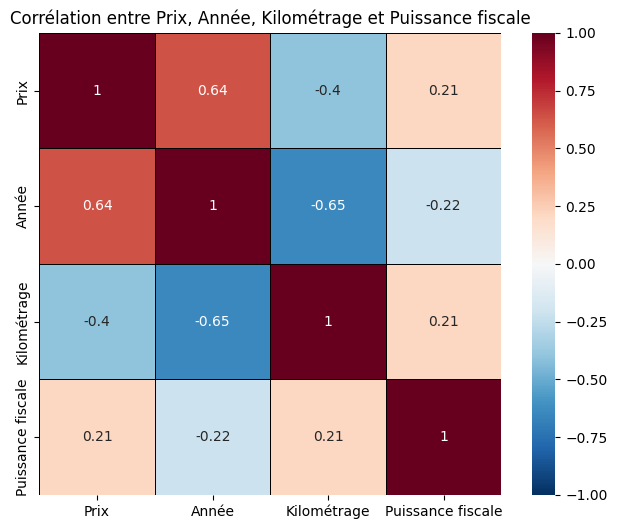

In [28]:
colonnes_interet = ['Prix', 'Année', 'Kilométrage', 'Puissance fiscale']

plt.figure(figsize=(8, 6))
sns.heatmap(df_concat[colonnes_interet].corr(),
            annot=True, cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5, linecolor='black')
plt.title('Corrélation entre Prix, Année, Kilométrage et Puissance fiscale')
plt.show()

## Histogramme des caracteristiques

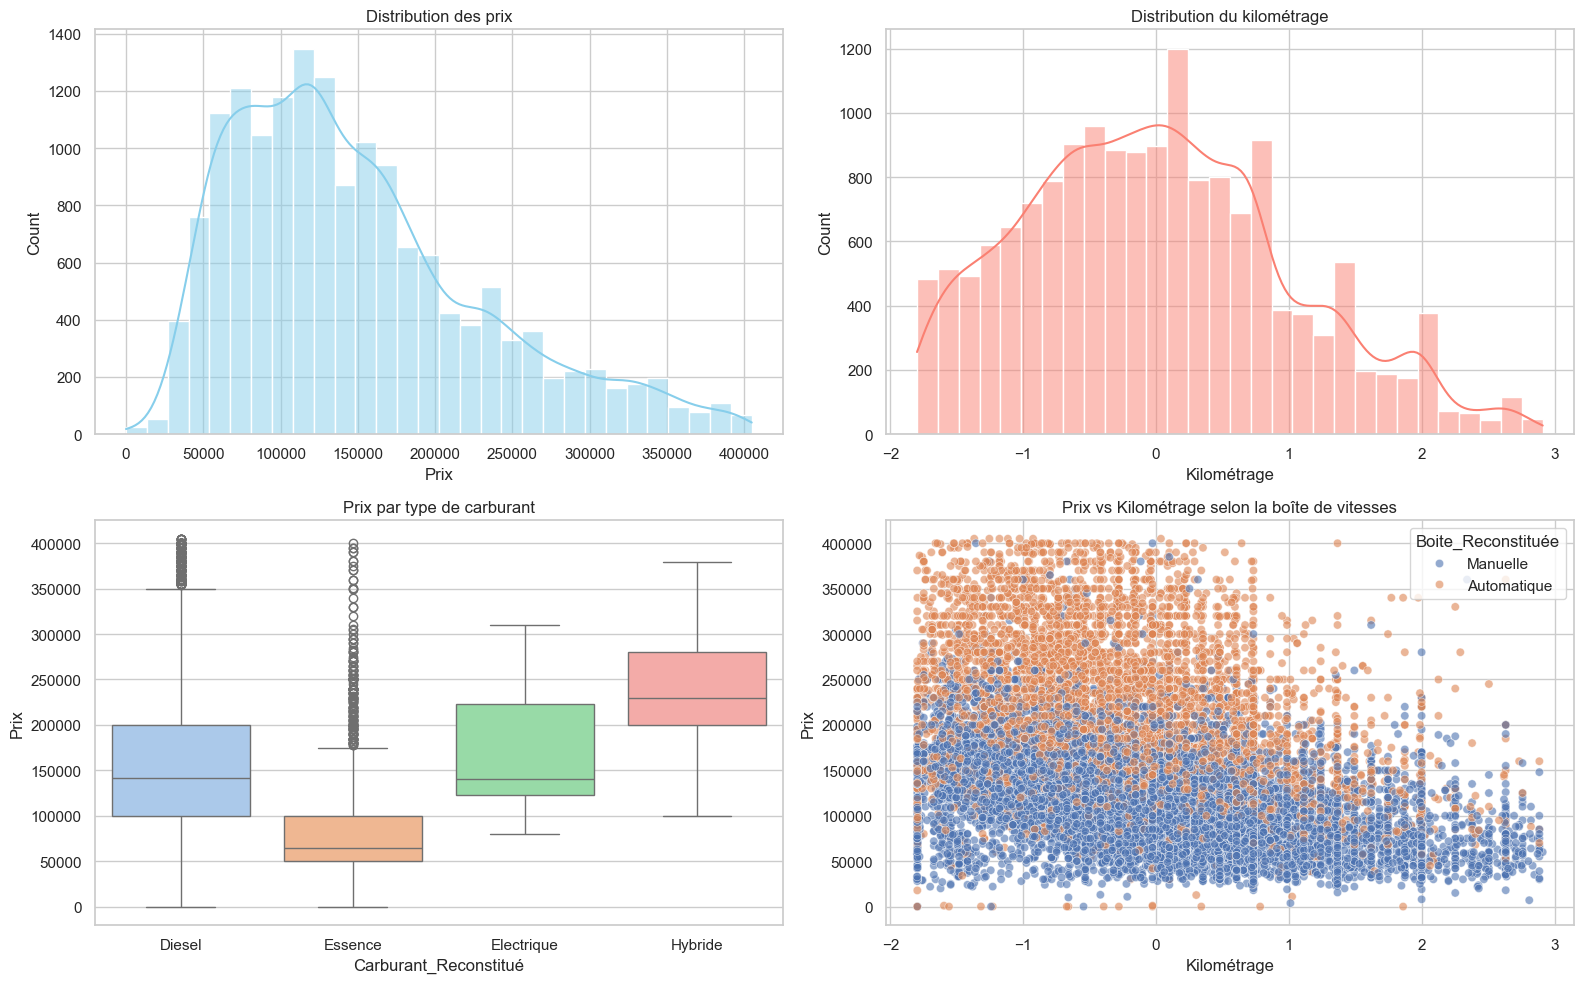

In [29]:
# Reconstituer les colonnes catégorielles après encodage
df_concat["Carburant_Reconstitué"] = df_concat.apply(
    lambda row: "Electrique" if row.get("electrique", 0) == 1 else
                "Essence" if row.get("essence", 0) == 1 else
                "Hybride" if row.get("hybride", 0) == 1 else
                "Diesel", axis=1)

df_concat["Boite_Reconstituée"] = df_concat["Boite_manuelle"].apply(
    lambda x: "Manuelle" if x == 1 else "Automatique")

# Configurer le style
sns.set(style="whitegrid")
plt.figure(figsize=(16, 10))

# Histogramme du prix
plt.subplot(2, 2, 1)
sns.histplot(df_concat["Prix"], bins=30, kde=True, color="skyblue")
plt.title("Distribution des prix")

# Histogramme du kilométrage
plt.subplot(2, 2, 2)
sns.histplot(df_concat["Kilométrage"], bins=30, kde=True, color="salmon")
plt.title("Distribution du kilométrage")

# Boîte à moustaches - Prix par type de carburant
plt.subplot(2, 2, 3)
sns.boxplot(x="Carburant_Reconstitué", y="Prix", data=df_concat, palette="pastel", hue="Carburant_Reconstitué", legend=False)
plt.title("Prix par type de carburant")

# Nuage de points - Prix vs Kilométrage selon la boîte de vitesses
plt.subplot(2, 2, 4)
sns.scatterplot(x="Kilométrage", y="Prix", hue="Boite_Reconstituée", data=df_concat, alpha=0.6)
plt.title("Prix vs Kilométrage selon la boîte de vitesses")

plt.tight_layout()
plt.show()

## Étude des facteurs clés influençant le prix

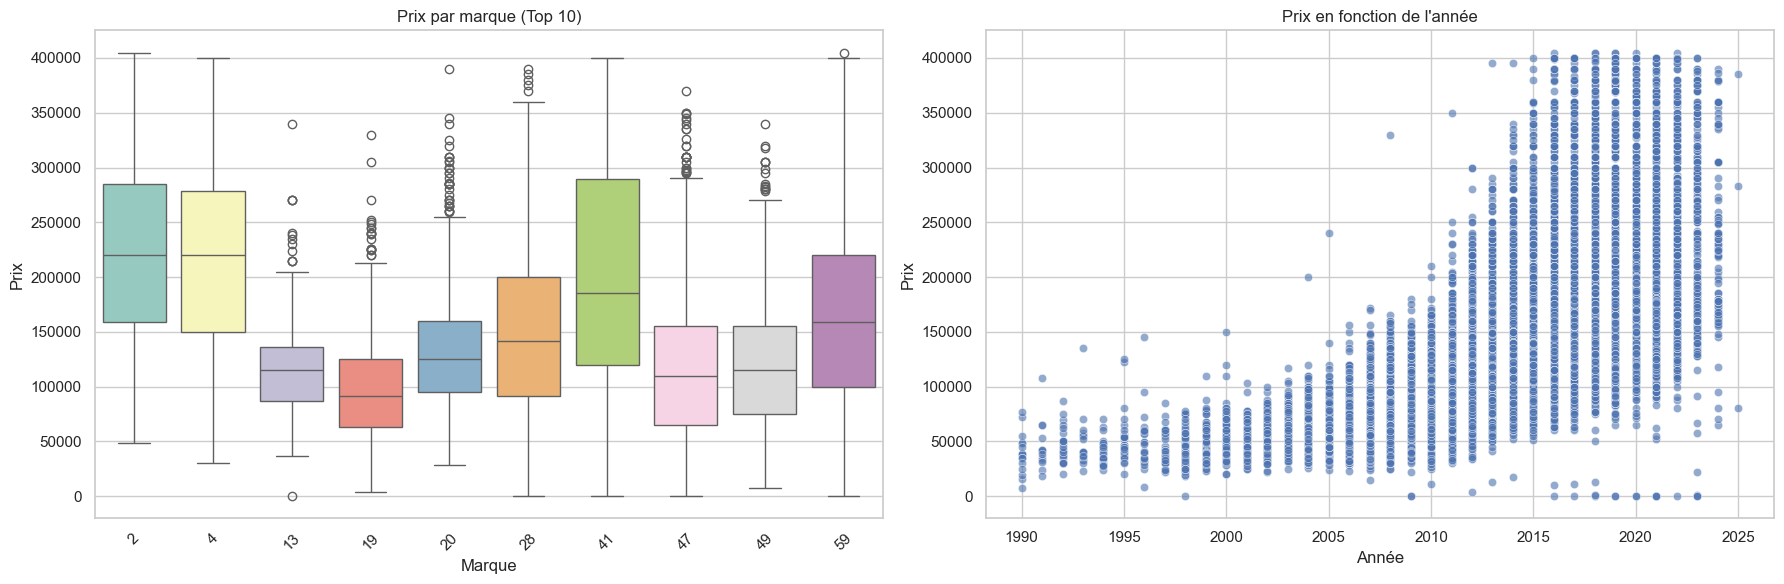

In [30]:
# Visualisation
plt.figure(figsize=(18, 6))  # Ajusté pour 1 ligne et 2 colonnes

# Boxplot du prix par marque (Top 10)
top_brands = df_concat["Marque"].value_counts().nlargest(10).index
plt.subplot(1, 2, 1)
sns.boxplot(x="Marque", y="Prix", data=
            df_concat[df_concat["Marque"].isin(top_brands)], palette="Set3", hue="Marque", legend=False)
plt.xticks(rotation=45)
plt.title("Prix par marque (Top 10)")

# Scatter plot Prix vs Année
plt.subplot(1, 2, 2)
sns.scatterplot(x="Année", y="Prix", data=df_concat, alpha=0.6)
plt.title("Prix en fonction de l'année")

plt.tight_layout()
plt.show()

In [31]:
codes = [2, 4, 13, 19, 20, 28, 41, 47, 49, 59]
marques_tendance = marque_encoder.inverse_transform(codes)

print("Marques tendance :", marques_tendance)

Marques tendance : ['audi' 'bmw' 'dacia' 'fiat' 'ford' 'hyundai' 'mercedes-benz' 'peugeot'
 'renault' 'volkswagen']


# Sélection et entraînement des modèles
> Réf. rapport, pp. 28-31

## Split dataset

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## RandomForest

In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest:
R2 Score: 0.8893898263560114
RMSE: 27112.928014292862


## Gradient Boosting

In [34]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize the model
gb_model = GradientBoostingRegressor(n_estimators=100,
                                     learning_rate=0.1, random_state=42)

# Train the model
gb_model.fit(X_train, y_train)

# Predictions
y_pred_gb = gb_model.predict(X_test)

# Evaluate the model
print("Gradient Boosting:")
print("R2 Score:", r2_score(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

Gradient Boosting:
R2 Score: 0.8458270231301596
RMSE: 32009.80385942184


## Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression

# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
print("Linear Regression:")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

Linear Regression:
R2 Score: 0.6900477667961348
RMSE: 45386.45564931232


## SVR

In [36]:
from sklearn.svm import SVR

# Initialize the model
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)

# Train the model
svr_model.fit(X_train, y_train)

# Predictions
y_pred_svr = svr_model.predict(X_test)

# Evaluate the model
print("SVR:")
print("R2 Score:", r2_score(y_test, y_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_svr)))

SVR:
R2 Score: 0.03511327499313044
RMSE: 80078.70653817483


## Comparaison de modèles

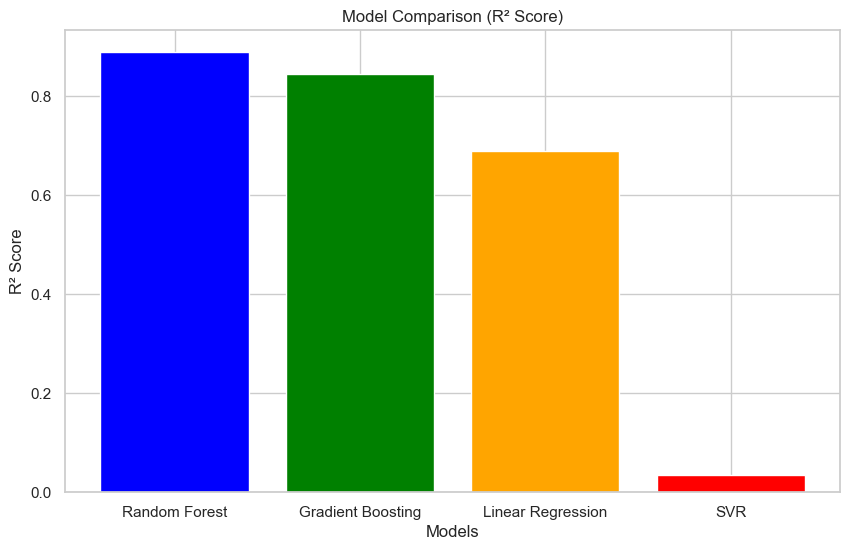

In [37]:
# Store results in a dictionary
results = {
    "Random Forest": r2_score(y_test, y_pred_rf),
    "Gradient Boosting": r2_score(y_test, y_pred_gb),
    "Linear Regression": r2_score(y_test, y_pred_lr),
    "SVR": r2_score(y_test, y_pred_svr)
}

# Plot the comparison
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), 
        color=['blue', 'green', 'orange', 'red'])
plt.title('Model Comparison (R² Score)')
plt.xlabel('Models')
plt.ylabel('R² Score')
plt.show()

## Entrainer Le best Model RandomForestRegressor avec les valeurs optimales des hyperparamètres

### GridSearchCV

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

# Résultats
print("Best parameters:", grid_search.best_params_)
print("Best score:", -grid_search.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters: {'max_depth': 20, 'max_features': None, 'min_samples_split': 5, 'n_estimators': 200}
Best score: 743975921.8302646


### Entraîner le modèle

In [45]:
rf_model_op = RandomForestRegressor(n_estimators=200, max_depth=20, max_features=None, min_samples_split=5, random_state=42)
rf_model_op.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, max_features=None, min_samples_split=5,
                      n_estimators=200, random_state=42)

### Evaluer le modèle

In [46]:
y_pred = rf_model_op.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 719045411.4278709
R² Score: 0.8918071524341249


### Prédiction vs Réel

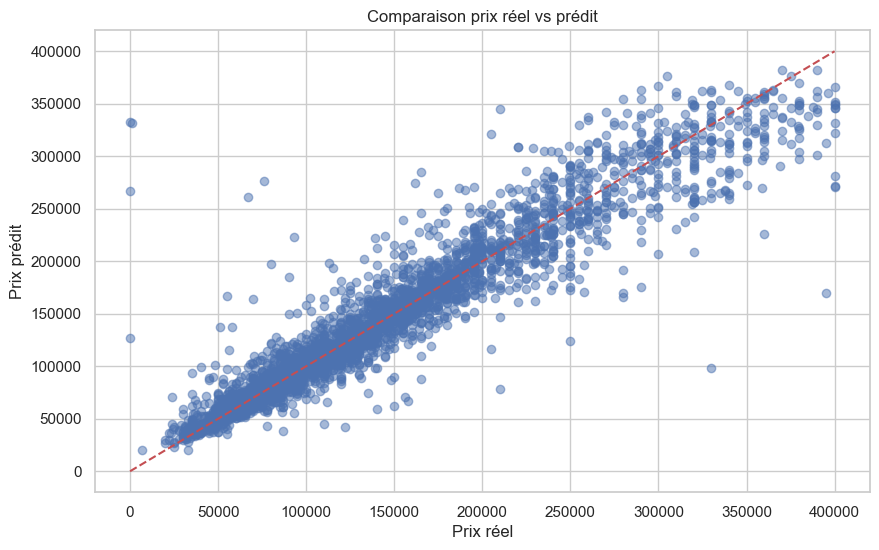

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Prix réel')
plt.ylabel('Prix prédit')
plt.title('Comparaison prix réel vs prédit')
plt.show()

### Importance des features

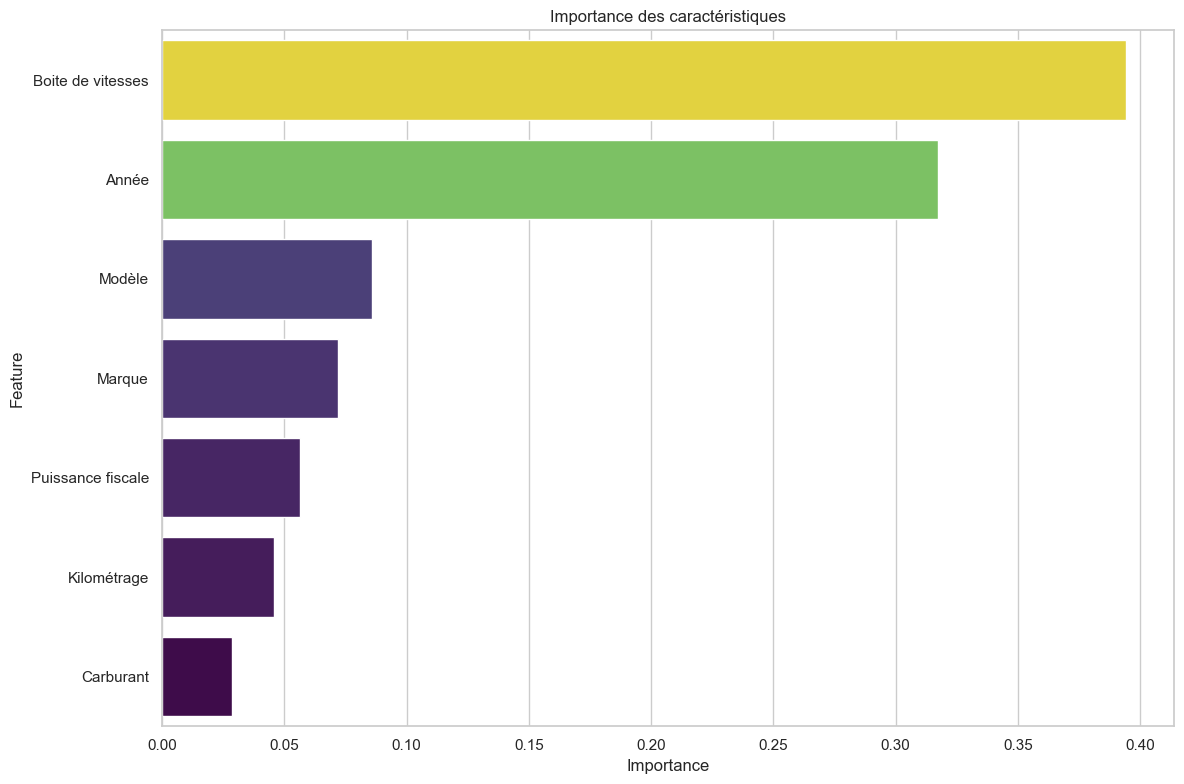

In [48]:
# Créer une copie pour regroupement visuel
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model_op.feature_importances_
})

# Regrouper les variables encodées manuellement
feature_importance['Feature'] = feature_importance['Feature'].replace({
    'diesel': 'Carburant',
    'essence': 'Carburant',
    'electrique': 'Carburant',
    'hybride': 'Carburant',
    'Boite_manuelle': 'Boite de vitesses'
})

# Agréger les importances par "entité"
feature_importance = feature_importance.groupby('Feature', as_index=False)['Importance'].sum()

# Trier par importance décroissante
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Affichage
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis',hue="Importance", legend=False)
plt.title('Importance des caractéristiques')
plt.tight_layout()
plt.show()

### Visualisation des Résidus

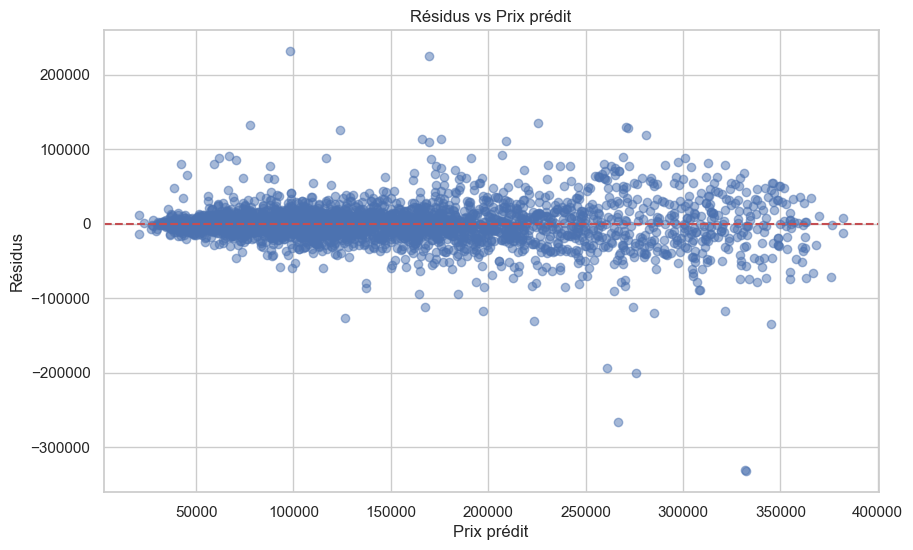

In [49]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Prix prédit')
plt.ylabel('Résidus')
plt.title('Résidus vs Prix prédit')
plt.show()

## Extraction du modèle après l'apprentissage 

In [50]:
import pickle
import joblib

joblib.dump(rf_model, 'rf_model_op.joblib', compress=3)

# with open('rf_model_op.pkl', 'wb') as f:
#     pickle.dump(rf_model, f)

with open('marque_encoder.pkl', 'wb') as f:
    pickle.dump(marque_encoder, f)

with open('modele_encoder.pkl', 'wb') as f:
    pickle.dump(modele_encoder, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)